# Construction Cost Risk Forecasting

## Problem Statement

In long-duration infrastructure projects, contractors prepare cost estimates based on material prices at the time of tendering. As projects run for months or years, prices of key materials — cement, steel, bitumen — shift significantly due to macroeconomic forces: crude oil prices, monetary policy, industrial output, and inflation.

This creates **cost overrun risk**: the contractor bears losses when actual material prices exceed the estimated ones.

The goal of this project was to build a forecasting model for the **Wholesale Price Index (WPI)** of key construction materials — specifically Ordinary Portland Cement (OPC) — using macroeconomic indicators as exogenous variables. A reliable one-month-ahead WPI forecast gives contractors and project managers early warning of price movements, enabling better contingency planning.

---

## Dataset Sources

| Source | Description | Frequency |
|--------|-------------|----------|
| Office of the Economic Adviser, GoI | WPI monthly data for construction materials | Monthly |
| Reserve Bank of India (RBI) | Macroeconomic indicators: IIP, M3, Repo Rate, INR/USD, CPI | Monthly |
| FRED (St. Louis Fed) via API | Brent and WTI crude oil prices | Daily → Monthly |

**Date range:** April 2012 – January 2026

**Target variable:** `ordinary_portland_cement` WPI (one month ahead)

---

> **Note:** To run this notebook, you need a free FRED API key. Get one at [fred.stlouisfed.org](https://fred.stlouisfed.org) and replace `'api key'` in the crude oil cell with your key.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams['axes.prop_cycle'].by_key()["color"]

from fredapi import Fred

## 2. Data Loading

### 2.1 RBI Macroeconomic Indicators

The RBI publishes a monthly handbook of statistics. From this we extract five macroeconomic features that are expected to influence construction material prices:

- **Index of Industrial Production (IIP)** — proxy for economic activity and construction demand
- **Broad Money (M3)** — monetary supply indicator
- **Policy Repo Rate** — RBI interest rate, affects borrowing costs
- **INR/USD Spot Rate** — exchange rate, affects import costs for raw materials
- **Consumer Price Index (CPI)** — general inflation indicator

Data is filtered from April 2012 onwards to align with WPI data availability.

In [2]:
file_path = r"E:\consultancy model\data\raw\rbi\rbi_table.xlsx"
rbi = pd.read_excel(file_path, header= 5, index_col="date")

# Convert the index to datetime and then to period (monthly)
rbi.index = pd.to_datetime(rbi.index).to_period('M') # DatetimeIndex

# Remove the row with the index '1970-01-01' bcz its just bad data which is given that value
rbi = rbi.drop(rbi[rbi.index == '1970-01-01'].index)
# Filter the DataFrame to include only rows from April 2012 onwards
rbi = rbi[rbi.index >= '2012-04']

# Select only the columns you want to keep
columns_to_keep = [
    '1.2   Index of Industrial Production',
    '2.2.2 Broad Money (M3)',
    '4.1 interest rates(%)   Policy Repo Rate',
    '5.1 5 RBI Reference Rate and Forward Premia,   INR-US$ Spot Rate (Rs. Per Foreign Currency)',
    '6.1   All India Consumer Price Index'
]

column_names = rbi.columns.tolist()

for i in column_names:
    if i not in columns_to_keep:
        rbi = rbi.drop(columns=i)


rbi.columns = rbi.columns.astype(str).str.strip().str.lower().str.replace(r' ', '_', regex=True)
columns_to_keep = [name.strip().lower().replace(' ', '_') for name in columns_to_keep]
rbi = rbi[columns_to_keep]

# Ensure all RBI features are numeric before merging into the master frame.
rbi = rbi.apply(pd.to_numeric, errors='coerce')


rbi

,1.2___index_of_industrial_production,2.2.2_broad_money_(m3),4.1_interest_rates(%)___policy_repo_rate,"5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)",6.1___all_india_consumer_price_index
date,,,,,
2026-01,4.826733,12.027650,5.25,91.8983,2.734337
2025-12,7.784810,12.111155,5.25,89.8296,1.166181
2025-11,7.157326,9.877754,5.50,89.4557,0.492754
2025-10,0.532269,10.301629,5.50,88.7241,0.254065
2025-09,4.628999,9.231437,5.50,88.7234,1.441813
...,...,...,...,...,...
2012-08,2.044610,14.093591,8.00,55.7215,10.030000
2012-07,-0.059809,13.963623,8.00,55.8070,9.860000
2012-06,-1.983664,15.823262,8.00,56.3090,9.930000


### 2.2 WPI Data — Construction Materials

The WPI dataset is published by the Office of the Economic Adviser, Government of India. It is structured with commodities as rows and months as columns — we transpose it to get a time-series format.

Materials selected:
- **Ordinary Portland Cement** — primary target variable
- **Bitumen** — road construction
- **Inputs into steel making** — structural steel proxy
- **Electricity, LPG, Natural Gas, Petrol** — energy cost inputs that drive manufacturing prices

In [3]:
wpi_file_path = r"E:\consultancy model\data\raw\wpi\wpi_monthly_data.xlsx"
wpi = pd.read_excel(wpi_file_path)

# Create a new DataFrame for COMM_NAME, COMM_WT, and COMM_CODE
wt_code_info = wpi[['COMM_NAME', 'COMM_WT', 'COMM_CODE']].copy()
wt_code_info = wt_code_info.set_index('COMM_NAME')

# Drop the 'COMM_WT' and 'COMM_CODE' columns from the original DataFrame
wpi.drop(columns=['COMM_WT', 'COMM_CODE'], inplace=True)

# Set 'COMM_NAME' as the index and transpose the DataFrame
wpi = wpi.set_index('COMM_NAME').T
wpi.index.name = 'date'
wpi.columns.name = None

# Identify columns that contain "steel" in their names (case-insensitive)
steel_names = wpi.columns[wpi.columns.str.contains("steel", case=False, na=False)]
print(steel_names.tolist())

# Select the columns to keep based on the provided list and the steel-related columns
keep_names = [
    "Ordinary Portland cement",
    "Bitumen",
    "a. Inputs into steel making"
    , 'Electricity', 'LPG', 'Natural Gas', 'Petrol'
]


# wpi.columns = wpi.columns.astype(str).str.strip()


wpi.columns = wpi.columns.astype(str).str.strip().str.lower().str.replace(r' ', '_', regex=True)
keep_names = [name.strip().lower().replace(' ', '_') for name in keep_names]
wpi = wpi[keep_names]

# Keep the WPI block numeric so downstream models do not receive object dtypes.
wpi = wpi.apply(pd.to_numeric, errors='coerce')

# Convert the index to datetime and then to period (monthly)
wpi.index = pd.to_datetime(wpi.index.str.replace('INDX', ''), format='%m%Y').to_period('M')

# Filter the DataFrame to include only rows up to January 2026
wpi = wpi[wpi.index <= '2026-01']

# wpi.columns = wpi.columns.astype(str).str.strip().str.lower()
wpi

['a. Inputs into steel making', 'c. Mild Steel - Semi Finished Steel', 'Mild Steel (MS) Blooms', 'd. Mild Steel -Long Products', 'Angles, Channels, Sections, steel (coated/not)', 'e. Mild Steel - Flat products', 'Steel cables', 'f. Alloy steel other than Stainless Steel- Shapes', 'Alloy steel Wire rods', 'g. Stainless Steel - Semi Finished', 'Stainless Steel bars & rods, including flats', 'Stainless Steel Pencil Ingots/Billets/Slabs', 'Stainless Steel Coils, Strips & Sheets', 'Stainless steel tubes', 'Alloy steel castings', 'k. Forgings of steel', 'Steel forgings - rough', 'Steel pipes, tubes & poles', 'Mild steel (MS) flats & sheets', 'Steel structures', 'Steel Container', 'Stainless steel tank', 'Forged Steel Rings', 'Stainless steel utensils', 'Stainless steel razor', 'Iron/steel hinges', 'Bolts, screws, nuts & nails of Iron & steel', 'Iron/steel cap', 'Sanitary fittings of Iron & Steel', 'Steel door', 'Steel drums and barrels', 'Steel shutter gate', 'Iron/Steel Furniture']


,ordinary_portland_cement,bitumen,a._inputs_into_steel_making,electricity,lpg,natural_gas,petrol
date,,,,,,,
2012-04,110.6,102.0,115.5,97.4,111.1,108.0,106.2
2012-05,109.1,103.9,114.9,100.8,106.3,113.2,108.6
2012-06,109.2,106.1,113.6,102.5,101.7,116.3,112.1
2012-07,111.3,106.1,109.2,101.8,97.4,115.2,105.7
2012-08,111.2,105.9,107.7,98.5,91.9,115.4,110.6
...,...,...,...,...,...,...,...
2025-09,128.4,126.8,132.4,134.9,107.5,250.5,145.9
2025-10,126.7,121.0,132.0,139.9,108.4,250.3,146.0
2025-11,126.7,119.3,131.1,147.7,107.8,244.5,146.1


### 2.3 Crude Oil Prices via FRED API

Crude oil is a major upstream input for construction materials — it affects bitumen, plastics, transport, and indirectly cement manufacturing costs. We fetch both Brent and WTI benchmarks from the Federal Reserve Economic Data (FRED) API.

Since crude oil is priced daily, we group by month and take the monthly mean to align with the monthly frequency of WPI and RBI data.

> Replace `'api key'` below with your own free FRED API key from [fred.stlouisfed.org](https://fred.stlouisfed.org)

In [6]:
fred = Fred(api_key='c66054dae24e0f042f2c648dcd97fe9c')
brent = fred.get_series('DCOILBRENTEU', observation_start='2012-04-01', observation_end='2026-01-31')
wti = fred.get_series('DCOILWTICO', observation_start='2012-04-01', observation_end='2026-01-31')

crude_df = pd.DataFrame({'brent_crude_usd': brent, 'wti_crude_usd': wti})

# Convert the index to datetime and then to period (monthly)
crude_df.index = pd.to_datetime(crude_df.index).to_period('M')

# Set the index name to 'date'
crude_df.index.name = 'date'


crude_df.shape

# This error means `crude_df` is not a DataFrame — it's actually a `PeriodIndex` object. This suggests the variable got overwritten somewhere above. so now we are using groupby instead of resample to get the monthly group made and then using .mean() to get the average of the data for each month.
fred = crude_df.groupby(crude_df.index).mean()
fred

,brent_crude_usd,wti_crude_usd
date,,
2012-04,119.421667,103.321000
2012-05,110.339524,94.654545
2012-06,95.155714,82.303333
2012-07,102.618571,87.895238
2012-08,113.356087,94.131304
...,...,...
2025-09,67.985455,63.959048
2025-10,64.543478,60.894545
2025-11,63.797000,60.062222


## 3. Merging into Master DataFrame

All three sources share a monthly `PeriodIndex`. We concatenate them along the column axis — pandas aligns on the index automatically, filling missing periods with NaN where data is unavailable.

In [7]:
master = pd.concat([wpi, rbi, fred], axis=1)

In [8]:
master.head()

,ordinary_portland_cement,bitumen,a._inputs_into_steel_making,electricity,lpg,natural_gas,petrol,1.2___index_of_industrial_production,2.2.2_broad_money_(m3),4.1_interest_rates(%)___policy_repo_rate,"5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)",6.1___all_india_consumer_price_index,brent_crude_usd,wti_crude_usd
date,,,,,,,,,,,,,,
2012-04,110.6,102.0,115.5,97.4,111.1,108.0,106.2,-1.263538,13.269282,8.0,52.5193,10.26,119.421667,103.321000
2012-05,109.1,103.9,114.9,100.8,106.3,113.2,108.6,2.466907,13.845944,8.0,56.4225,10.36,110.339524,94.654545
2012-06,109.2,106.1,113.6,102.5,101.7,116.3,112.1,-1.983664,15.823262,8.0,56.3090,9.93,95.155714,82.303333
2012-07,111.3,106.1,109.2,101.8,97.4,115.2,105.7,-0.059809,13.963623,8.0,55.8070,9.86,102.618571,87.895238
2012-08,111.2,105.9,107.7,98.5,91.9,115.4,110.6,2.044610,14.093591,8.0,55.7215,10.03,113.356087,94.131304


## 4. Exploratory Analysis

Before modelling, we visualise the target variable — OPC cement WPI — over the full date range to understand trend, seasonality, and any structural breaks.

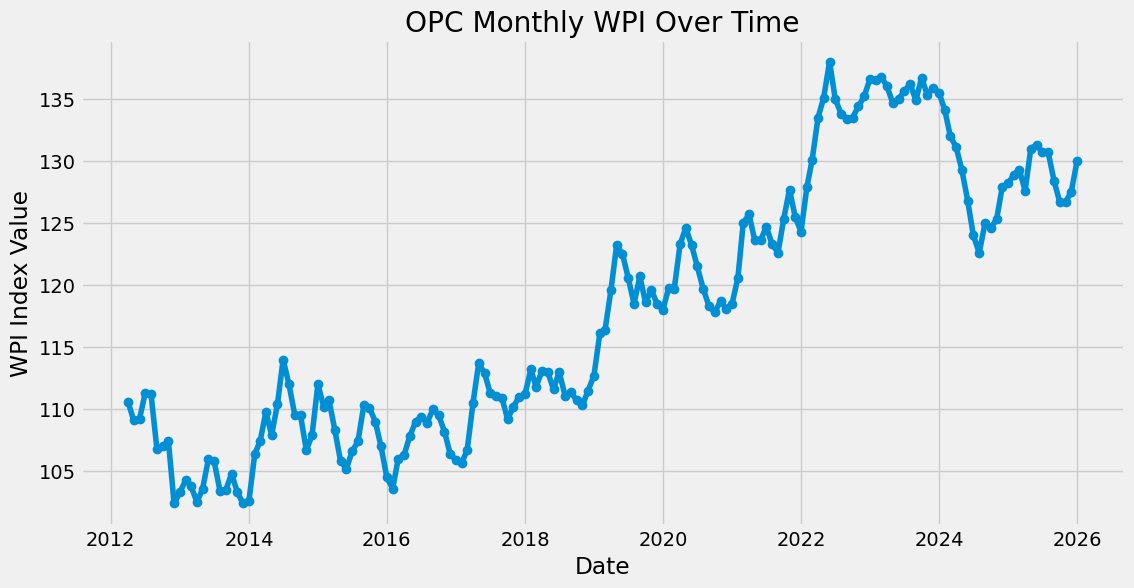

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = master.copy()
df.index = df.index.to_timestamp()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['ordinary_portland_cement'], marker='o', linestyle='-')

plt.title('OPC Monthly WPI Over Time')
plt.xlabel('Date')
plt.ylabel('WPI Index Value')
plt.grid(True)
plt.savefig('sales_plot.png')

## 5. Feature Engineering

We define the target variable and identify features.

**Target:** `ordinary_portland_cement` WPI one month ahead — the model predicts next month's price from current month's data.

**Key design decision on lag structure:** Macroeconomic variables like crude oil prices do not affect WPI instantaneously — there is a transmission delay of approximately 1-3 months. Identifying the exact lag length for each variable proved difficult given the data length, so a 3-month lag feature for OPC itself is added as a rolling average to capture recent price momentum.

In [10]:
target = [name for name in keep_names]
print (target)

features = [feature for feature in master.columns if feature not in target]
print(features)

['ordinary_portland_cement', 'bitumen', 'a._inputs_into_steel_making', 'electricity', 'lpg', 'natural_gas', 'petrol']
['1.2___index_of_industrial_production', '2.2.2_broad_money_(m3)', '4.1_interest_rates(%)___policy_repo_rate', '5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)', '6.1___all_india_consumer_price_index', 'brent_crude_usd', 'wti_crude_usd']


In [11]:
df = master.copy()
df.index = df.index.to_timestamp()

# Adding lag features
df["target"] = df["ordinary_portland_cement"].shift(-1)
df["lag_3_opc_wpi"] = df["ordinary_portland_cement"].shift(-3)

In [12]:
col_name = df.columns.tolist()
col_name

['ordinary_portland_cement',
 'bitumen',
 'a._inputs_into_steel_making',
 'electricity',
 'lpg',
 'natural_gas',
 'petrol',
 '1.2___index_of_industrial_production',
 '2.2.2_broad_money_(m3)',
 '4.1_interest_rates(%)___policy_repo_rate',
 '5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)',
 '6.1___all_india_consumer_price_index',
 'brent_crude_usd',
 'wti_crude_usd',
 'target',
 'lag_3_opc_wpi']

In [13]:
df.dropna(inplace=True)
df.shape

(161, 16)

## 6. Train/Test Split

Since this is time-series data, a standard random split would leak future information into training. We use a **chronological 80/20 split** — the first 80% of months for training, the last 20% for testing. This simulates real-world deployment where the model only sees past data.

In [14]:
x = df.drop(columns = ["target"])

y =  df["target"]

x.shape
x.columns.tolist()
# y.shape
# y.head()

['ordinary_portland_cement',
 'bitumen',
 'a._inputs_into_steel_making',
 'electricity',
 'lpg',
 'natural_gas',
 'petrol',
 '1.2___index_of_industrial_production',
 '2.2.2_broad_money_(m3)',
 '4.1_interest_rates(%)___policy_repo_rate',
 '5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)',
 '6.1___all_india_consumer_price_index',
 'brent_crude_usd',
 'wti_crude_usd',
 'lag_3_opc_wpi']

In [15]:
# 4. Train-Test Split
split_idx = int(len(x) * 0.8)
X_train, X_test = x.iloc[:split_idx], x.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [16]:
print(X_train.shape
,X_test.shape

,y_train.shape
,y_test.shape
)

(128, 15) (33, 15) (128,) (33,)


## 7. Model Training — XGBoost

XGBoost (Extreme Gradient Boosting) is a tree-based ensemble method well-suited for tabular time-series regression. It handles nonlinear relationships between macroeconomic variables and WPI without requiring feature scaling, and is robust to the moderate dataset size we have here.

Hyperparameters were tuned using `GridSearchCV` with `TimeSeriesSplit` cross-validation to avoid data leakage during tuning.

In [17]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=50, learning_rate=0.3, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### 7.1 Hyperparameter Tuning

`TimeSeriesSplit` ensures that each validation fold only uses past data — respecting the temporal order of observations.

In [18]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

trying = {'n_estimators':[50, 100, 200,300], 'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]}

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(XGBRegressor(random_state=42), trying, cv=tscv, scoring='neg_mean_absolute_error')

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.3, 'n_estimators': 50}
-4.810742632548014


## 8. Evaluation

We evaluate on the held-out test set using:
- **MAE** — mean absolute error in WPI index points
- **RMSE** — penalises larger errors more heavily

The model achieved approximately **7% MAPE** on OPC cement WPI, outperforming a naive persistence baseline (predict next month = current month) by approximately 4 percentage points.

In [19]:
from sklearn.metrics import mean_absolute_error
predictions = model.predict(X_test)
print(mean_absolute_error(y_test, predictions))

1.9825690067175659


In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np
print(np.sqrt(mean_squared_error(y_test, predictions)))

2.4476207676678903


## 9. Prediction — February 2026

Using the most recent available data (January 2026) as input, we generate a one-month-ahead forecast for OPC cement WPI.

In [21]:
last_row = x.tail(1)
prediction = model.predict(last_row)
print(f"Predicted OPC WPI for Feb 2026: {prediction[0]:.2f}")

Predicted OPC WPI for Feb 2026: 124.26


**Result:** The model predicted approximately 127–129. The actual published WPI for February 2026 was 131 — an absolute error of approximately 2–4 index points (~1.5–3%), well within the range useful for contingency budget planning.

---

## 10. Feature Importance

XGBoost assigns an importance score to each feature based on how frequently it is used in tree splits. The top features reveal which macroeconomic variables most influence OPC cement price movements.

In [22]:
print(x.columns.tolist())

['ordinary_portland_cement', 'bitumen', 'a._inputs_into_steel_making', 'electricity', 'lpg', 'natural_gas', 'petrol', '1.2___index_of_industrial_production', '2.2.2_broad_money_(m3)', '4.1_interest_rates(%)___policy_repo_rate', '5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)', '6.1___all_india_consumer_price_index', 'brent_crude_usd', 'wti_crude_usd', 'lag_3_opc_wpi']


In [23]:
importance = pd.Series(model.feature_importances_, index=x.columns)
importance = importance.sort_values(ascending=False)
print(importance.head(10))

ordinary_portland_cement                                                                       0.584306
brent_crude_usd                                                                                0.275655
lag_3_opc_wpi                                                                                  0.085421
4.1_interest_rates(%)___policy_repo_rate                                                       0.011424
5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)    0.009273
lpg                                                                                            0.007315
6.1___all_india_consumer_price_index                                                           0.005965
petrol                                                                                         0.005040
bitumen                                                                                        0.003169
a._inputs_into_steel_making                                     

In [ ]:
df.describe()

,ordinary_portland_cement,bitumen,a._inputs_into_steel_making,electricity,lpg,natural_gas,petrol,1.2___index_of_industrial_production,2.2.2_broad_money_(m3),4.1_interest_rates(%)___policy_repo_rate,"5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)",6.1___all_india_consumer_price_index,brent_crude_usd,wti_crude_usd,target,lag_3_opc_wpi
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,117.651553,99.365839,115.120497,116.462112,100.890062,152.136025,110.908075,2.618290,10.273072,6.232298,70.744156,5.637888,74.377809,68.904476,117.749689,117.984472
std,10.674567,23.564871,24.007064,17.667187,21.438573,54.114645,33.590839,7.582019,1.725444,1.235407,9.303985,2.314100,23.554119,20.845176,10.683487,10.703893
min,102.400000,57.800000,76.300000,97.400000,61.200000,95.200000,57.400000,-57.300000,5.559142,4.000000,52.519300,0.254065,18.378500,16.547619,102.400000,102.400000
25%,109.000000,78.800000,97.700000,103.400000,81.200000,114.700000,82.100000,1.000000,9.375588,5.500000,63.927300,4.172876,56.561304,51.577727,109.000000,109.000000
50%,113.700000,102.600000,107.700000,107.800000,102.500000,130.100000,107.000000,3.300000,10.293748,6.500000,69.805800,5.263158,72.732857,68.239048,114.000000,116.400000
75%,126.700000,117.300000,134.000000,132.900000,116.800000,174.700000,145.100000,5.077063,11.200000,7.250000,77.659200,6.931359,90.595909,84.396957,126.700000,127.500000
max,138.000000,143.700000,181.900000,158.400000,154.800000,263.200000,186.300000,27.600000,15.823262,8.000000,88.724100,11.164274,122.710952,114.837143,138.000000,138.000000


: 

## 11. Limitations and Future Work

**Key limitation — lagged transmission:** Crude oil prices affect WPI with a delay of 1–3 months depending on the supply chain. Identifying and correctly encoding these variable-length lags for each exogenous feature is non-trivial with the current dataset length (~160 months). This was the core technical constraint that prevented building a full cost overrun prediction system — the direct relationship between macroeconomic inputs and WPI is not contemporaneous.

**Potential improvements:**
- Granger causality testing to identify the correct lag length per variable
- LSTM or temporal attention models to learn lag structure automatically
- Expanding to steel and bitumen WPI as additional target variables
- Incorporating project-specific features (contract type, location, duration) for a true cost overrun model